# 03 — Modeling: IndoBERT + MLP Classifier (PRDECT-ID, 5-Class Emotion)

Dataset: PRDECT-ID — 5 kelas emosi: Love, Happiness, Anger, Fear, Sadness

**Pipeline:**
1. Load data train/test dari preprocessing
2. Extract IndoBERT CLS embeddings (training & test)
3. Train MLP Classifier (tanpa augmentasi)
4. Evaluasi (F1-macro, Confusion Matrix)
5. Save model & label map

In [1]:
## 0. Google Colab Setup
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Google Colab detected — mounting Drive & installing packages ...")
    from google.colab import drive
    drive.mount("/content/drive")

    DRIVE_PROJECT = "/content/drive/MyDrive/xai_lime_vs_shap"

    if os.path.isdir(DRIVE_PROJECT):
        os.chdir(DRIVE_PROJECT)
        print(f"CWD set to: {DRIVE_PROJECT}")
    else:
        print(f"WARNING: '{DRIVE_PROJECT}' not found. Please check your Drive path.")

    !pip install -q transformers datasets accelerate
else:
    print("Local environment detected — skipping Colab setup.")

Mounted at /content/drive
CWD set to: /content/drive/MyDrive/xai_lime_vs_shap


In [2]:
## 1. Imports & Config
import os, sys, warnings, json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import classification_report, confusion_matrix, f1_score

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

def find_project_root() -> Path:
    markers = ["data", "notebooks", "src"]
    candidate = Path.cwd()
    for _ in range(3):
        if all((candidate / m).exists() for m in markers):
            return candidate
        candidate = candidate.parent
    return Path.cwd()

PROJECT_ROOT  = find_project_root()
PROC_DIR      = PROJECT_ROOT / "data" / "processed"
MODEL_SAVE_DIR = PROJECT_ROOT / "outputs" / "prdect_indobert"
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BERT_MODEL_NAME = "indobenchmark/indobert-base-p1"

print(f"Project root : {PROJECT_ROOT}")
print(f"Processed dir: {PROC_DIR}")
print(f"Model save dir: {MODEL_SAVE_DIR}")
print(f"Device       : {DEVICE}")

Project root : /content/drive/MyDrive/xai_lime_vs_shap
Processed dir: /content/drive/MyDrive/xai_lime_vs_shap/data/processed
Model save dir: /content/drive/MyDrive/xai_lime_vs_shap/outputs/prdect_indobert
Device       : cuda


In [3]:
## 2. Load Train/Test Data
TRAIN_PATH = PROC_DIR / "prdect_train.csv"
TEST_PATH  = PROC_DIR / "prdect_test.csv"
LABEL_MAP_PATH = PROC_DIR / "prdect_label_map.json"

for p in [TRAIN_PATH, TEST_PATH, LABEL_MAP_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"File not found: {p}\nPlease run 02_preprocessing_prdect.ipynb first.")

df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

with open(LABEL_MAP_PATH) as f:
    label_map = json.load(f)

EMOTION_MAP = label_map["label2id"]
ID2EMOTION  = {int(k): v for k, v in label_map["id2label"].items()}
CLASS_NAMES = [ID2EMOTION[i] for i in range(len(ID2EMOTION))]

print(f"Train size: {len(df_train)}")
print(f"Test size : {len(df_test)}")
print(f"Classes   : {CLASS_NAMES}")

print("\nTrain distribution:")
print(df_train['emotion_label'].value_counts())

print("\nTest distribution:")
print(df_test['emotion_label'].value_counts())

X_train_raw = df_train['review_clean'].values
y_train     = df_train['label'].values
X_test_raw  = df_test['review_clean'].values
y_test      = df_test['label'].values

Train size: 4319
Test size : 1080
Classes   : ['happy', 'love', 'anger', 'fear', 'sadness']

Train distribution:
emotion_label
happy      1416
sadness     962
fear        736
love        646
anger       559
Name: count, dtype: int64

Test distribution:
emotion_label
happy      354
sadness    240
fear       184
love       162
anger      140
Name: count, dtype: int64


In [4]:
## 3. Load IndoBERT
print(f"Loading IndoBERT: {BERT_MODEL_NAME} ...")
tokenizer  = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
bert_model = AutoModel.from_pretrained(BERT_MODEL_NAME).to(DEVICE)
bert_model.eval()
print("IndoBERT loaded successfully.")

Loading IndoBERT: indobenchmark/indobert-base-p1 ...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

IndoBERT loaded successfully.


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

In [6]:
## 4. Extract IndoBERT CLS Embeddings
def get_embeddings(texts, batch_size=16):
    """Ekstrak CLS token embedding dari IndoBERT."""
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i: i + batch_size])
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(DEVICE)
        with torch.no_grad():
            outputs = bert_model(**inputs)
            cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_emb)
        if (i // batch_size) % 10 == 0:
            print(f"  Processing batch {i // batch_size + 1}/{(len(texts) + batch_size - 1) // batch_size} ...", end='\r')
    return np.vstack(embeddings)

print("Extracting training embeddings ...")
X_train_emb = get_embeddings(X_train_raw)
print(f"\nTrain embeddings: {X_train_emb.shape}")

print("\nExtracting test embeddings ...")
X_test_emb = get_embeddings(X_test_raw)
print(f"\nTest embeddings : {X_test_emb.shape}")

Extracting training embeddings ...
  Processing batch 261/270 ...
Train embeddings: (4319, 768)

Extracting test embeddings ...
  Processing batch 61/68 ...
Test embeddings : (1080, 768)


In [7]:
## 5. MLP Classifier (5-class)
class MLP(torch.nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, output_dim=5, dropout=0.3):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim, 128),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.net(x)

n_classes  = len(CLASS_NAMES)
classifier = MLP(input_dim=768, hidden_dim=256, output_dim=n_classes, dropout=0.3).to(DEVICE)
criterion  = torch.nn.CrossEntropyLoss()
optimizer  = torch.optim.AdamW(classifier.parameters(), lr=1e-3, weight_decay=0.01)
print(f"MLP initialized: 768 → 256 → 128 → {n_classes}")
print(f"Parameters: {sum(p.numel() for p in classifier.parameters()):,}")

MLP initialized: 768 → 256 → 128 → 5
Parameters: 230,405


Training MLP (30 epochs, batch=64) ...
  Epoch   5/30 | Loss: 0.5154
  Epoch  10/30 | Loss: 0.5191
  Epoch  15/30 | Loss: 0.5181
  Epoch  20/30 | Loss: 0.5155
  Epoch  25/30 | Loss: 0.5187
  Epoch  30/30 | Loss: 0.5196


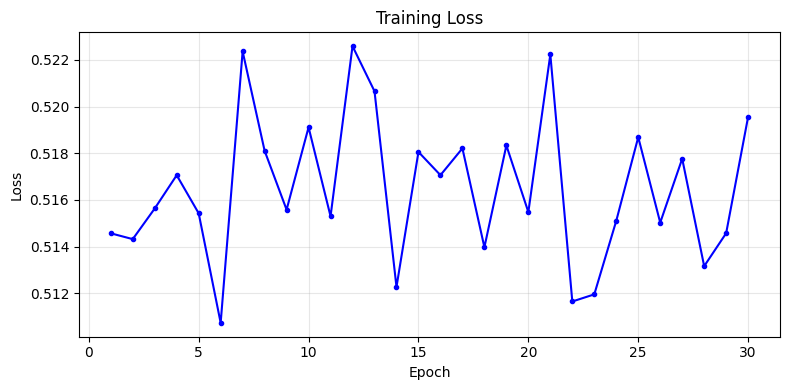

Training complete.


In [9]:
## 6. Training
EPOCHS     = 30
BATCH_SIZE = 64

# Prepare DataLoader
X_train_t  = torch.tensor(X_train_emb, dtype=torch.float32)
y_train_t  = torch.tensor(y_train, dtype=torch.long)
train_ds   = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses = []
print(f"Training MLP ({EPOCHS} epochs, batch={BATCH_SIZE}) ...")
for epoch in range(EPOCHS):
    classifier.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
        optimizer.zero_grad()
        outputs = classifier(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS} | Loss: {avg_loss:.4f}")

# Plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), train_losses, 'b-o', markersize=3)
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_SAVE_DIR / "training_loss.png", dpi=150)
plt.show()
print("Training complete.")


=== Classification Report ===
              precision    recall  f1-score   support

       happy       0.80      0.82      0.81       354
        love       0.67      0.62      0.64       162
       anger       0.56      0.50      0.53       140
        fear       0.53      0.52      0.52       184
     sadness       0.63      0.69      0.66       240

    accuracy                           0.67      1080
   macro avg       0.64      0.63      0.63      1080
weighted avg       0.67      0.67      0.67      1080

F1-Macro: 0.6327


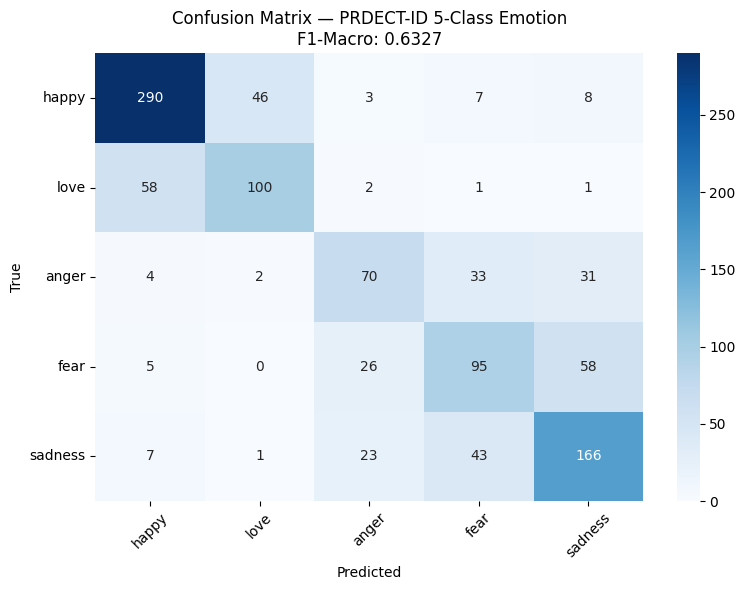

Confusion matrix saved.


In [10]:
## 7. Evaluation
classifier.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test_emb, dtype=torch.float32).to(DEVICE)
    logits   = classifier(X_test_t)
    preds    = torch.argmax(logits, dim=1).cpu().numpy()

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_test, preds, target_names=CLASS_NAMES))

f1_macro = f1_score(y_test, preds, average='macro')
print(f"F1-Macro: {f1_macro:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.title(f"Confusion Matrix — PRDECT-ID 5-Class Emotion\nF1-Macro: {f1_macro:.4f}")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(MODEL_SAVE_DIR / "confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved.")

## 8. Error Analysis — Analisis Misklasifikasi

Analisis ini bertujuan untuk:
1. Mengidentifikasi pola kesalahan prediksi model (pasangan kelas yang sering tertukar)
2. Menganalisis secara kualitatif contoh review yang salah diklasifikasi
3. Memahami kelemahan semantik model berdasarkan distribusi error

Analisis misklasifikasi merupakan bagian penting dari evaluasi model NLP
untuk memahami ambiguitas antar kelas emosi pada dataset berbahasa Indonesia.

In [11]:
## 8a. Ambil Prediksi Lengkap dengan Probabilitas
import pandas as pd
import numpy as np

classifier.eval()
with torch.no_grad():
    X_test_t   = torch.tensor(X_test_emb, dtype=torch.float32).to(DEVICE)
    logits_all = classifier(X_test_t)
    probs_all  = torch.softmax(logits_all, dim=-1).cpu().numpy()
    preds_all  = np.argmax(probs_all, axis=1)

# Buat DataFrame lengkap
df_test_ea = pd.read_csv(PROC_DIR / 'prdect_test.csv')
df_error = df_test_ea.copy()
df_error['true_label']   = y_test
df_error['pred_label']   = preds_all
df_error['true_emotion'] = [CLASS_NAMES[i] for i in y_test]
df_error['pred_emotion'] = [CLASS_NAMES[i] for i in preds_all]
df_error['confidence']   = probs_all.max(axis=1)
df_error['is_correct']   = (df_error['true_label'] == df_error['pred_label'])

# Filter misklasifikasi
df_mis = df_error[~df_error['is_correct']].copy()
n_mis  = len(df_mis)
n_tot  = len(df_error)

print("=== Error Analysis: Analisis Misklasifikasi ===")
print(f"Total sampel test    : {n_tot}")
print(f"Benar diklasifikasi  : {n_tot - n_mis} ({(n_tot-n_mis)/n_tot*100:.1f}%)")
print(f"Salah diklasifikasi  : {n_mis} ({n_mis/n_tot*100:.1f}%)")

# Frekuensi pasangan misklasifikasi
print("\n--- Pola Misklasifikasi (True → Predicted) ---")
confusion_pairs = (
    df_mis
    .groupby(['true_emotion', 'pred_emotion'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)
print(confusion_pairs.to_string(index=False))

# Top 10 error dengan confidence tertinggi (paling meyakinkan tapi salah)
print("\n--- Top 10 Misklasifikasi (Confidence Tertinggi) ---")
top_errors = df_mis.sort_values('confidence', ascending=False).head(10)
for _, row in top_errors.iterrows():
    txt = str(row['review_clean'])
    preview = txt[:100] + "..." if len(txt) > 100 else txt
    print(f"  True: {row['true_emotion']:8s} | Pred: {row['pred_emotion']:8s} | Conf: {row['confidence']:.3f}")
    print(f"  Review: {preview}")
    print()


=== Error Analysis: Analisis Misklasifikasi ===
Total sampel test    : 1080
Benar diklasifikasi  : 721 (66.8%)
Salah diklasifikasi  : 359 (33.2%)

--- Pola Misklasifikasi (True → Predicted) ---
true_emotion pred_emotion  count
        fear      sadness     58
        love        happy     58
       happy         love     46
     sadness         fear     43
       anger         fear     33
       anger      sadness     31
        fear        anger     26
     sadness        anger     23
       happy      sadness      8
       happy         fear      7
     sadness        happy      7
        fear        happy      5
       anger        happy      4
       happy        anger      3
       anger         love      2
        love        anger      2
        love         fear      1
        love      sadness      1
     sadness         love      1

--- Top 10 Misklasifikasi (Confidence Tertinggi) ---
  True: love     | Pred: happy    | Conf: 0.998
  Review: gampang dibawa bawa terlalu imut u

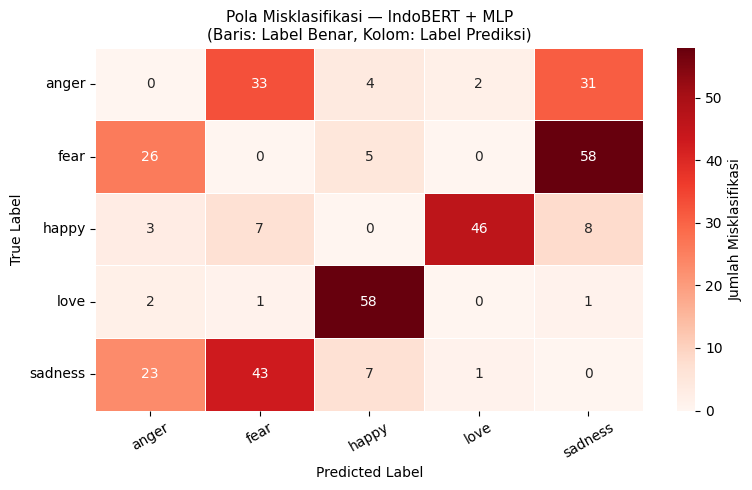

Error heatmap disimpan.
Error analysis CSV disimpan: /content/drive/MyDrive/xai_lime_vs_shap/outputs/prdect_indobert/error_analysis.csv


In [12]:
## 8b. Visualisasi Pola Misklasifikasi (Heatmap)
import matplotlib.pyplot as plt
import seaborn as sns

pivot_err = (
    confusion_pairs
    .pivot(index='true_emotion', columns='pred_emotion', values='count')
    .fillna(0).astype(int)
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot_err, annot=True, fmt='d', cmap='Reds',
    linewidths=0.5, cbar_kws={'label': 'Jumlah Misklasifikasi'}
)
plt.title(
    'Pola Misklasifikasi — IndoBERT + MLP\n'
    '(Baris: Label Benar, Kolom: Label Prediksi)',
    fontsize=11
)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=30); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(MODEL_SAVE_DIR / 'error_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Error heatmap disimpan.")

# Simpan error analysis ke CSV
error_path = MODEL_SAVE_DIR / 'error_analysis.csv'
df_mis[['review_clean', 'true_emotion', 'pred_emotion', 'confidence']].to_csv(
    error_path, index=False
)
print(f"Error analysis CSV disimpan: {error_path}")


In [13]:
## 8. Save Model & Assets
# Save MLP weights
torch.save(classifier.state_dict(), MODEL_SAVE_DIR / "mlp_classifier.pt")

# Save label map
with open(MODEL_SAVE_DIR / "label_map.json", 'w') as f:
    json.dump({"label2id": EMOTION_MAP, "id2label": ID2EMOTION}, f, indent=2)

# Save evaluation results
results = {
    "model": BERT_MODEL_NAME,
    "dataset": "PRDECT-ID",
    "n_classes": n_classes,
    "class_names": CLASS_NAMES,
    "train_size": len(X_train_raw),
    "test_size": len(X_test_raw),
    "f1_macro": round(f1_macro, 4),
    "augmentation": "none",
    "epochs": EPOCHS,
}
with open(MODEL_SAVE_DIR / "eval_results.json", 'w') as f:
    json.dump(results, f, indent=2)

print(f"All assets saved to: {MODEL_SAVE_DIR}")
print(f"  - mlp_classifier.pt")
print(f"  - label_map.json")
print(f"  - eval_results.json")
print(f"  - confusion_matrix.png")
print(f"  - training_loss.png")
print(f"\nF1-Macro: {f1_macro:.4f}")

All assets saved to: /content/drive/MyDrive/xai_lime_vs_shap/outputs/prdect_indobert
  - mlp_classifier.pt
  - label_map.json
  - eval_results.json
  - confusion_matrix.png
  - training_loss.png

F1-Macro: 0.6327
